<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Lab: Process Multimodal Data with LLMs**


Estimated time needed: **45** minutes


## **Scenario**


### **Background**

You transformed unstructured restaurant descriptions into a structured JSON knowledge base using LLMs. This allowed the app to reason over textual attributes such as cuisine type, pricing, and signature dishes in a consistent, machine-readable format.

However, the app’s data is not limited to text. It also includes **food recipes** and **user visit histories** that reference **images**, capturing visual information that text alone cannot fully describe, such as presentation style, ingredients, and portion details. To unlock this information and integrate it with the original databases, you will use multimodal GenAI capabilities to convert images into descriptive text and enrich the structured knowledge you have.


### **The challenge**

Images are inherently unstructured and cannot be directly stored or queried in a text-based knowledge system. To make them usable, you must first **generate high-quality textual descriptions** that summarize the visual content of each image.

Your challenge in this lab is to:

* Apply image captioning to generate descriptive text for food images
* Align and merge image captions with the corresponding recipe and restaurant JSON records
* Extend the existing structured knowledge base with multimodal context while preserving a consistent schema

By the end of this lab, you will have enriched your restaurant knowledge base with visual insights. You will bridge text and images into a unified, machine-accessible representation, setting the stage for more intelligent multimodal reasoning in later assignments.


## **Objectives**

In this lab, you will write a Python program that will:

* Load food recipe and user visit data containing image references
* Use a multimodal foundation model to generate textual captions for food images
* Integrate the generated image captions into the existing structured JSON data
* Produce an enriched multimodal JSON knowledge file for downstream applications


## **Important: About the lab environment**


Please be aware that sessions for this lab environment are not persisted. Every time you connect to this lab, a new environment is created for you. Any data you may have saved in the earlier session would get lost. Plan to complete these labs in a single session, to avoid losing your data.


## **Screenshot requirement for this lab**


You will be prompted to take a screenshot and save it on your own device. You will need this screenshot either to answer graded quiz questions or to upload as your submission for the Final Project at the end of this course. You can use various free screen-grabbing tools or your operating system's shortcut keys to do this (for example, `Alt+PrintScreen` on Windows and `Command+shift+4` on Mac).
**Note**: The screenshot can be saved with either the **.jpg** or **.png** extension.


----


## **Set up the lab environment**


For this lab, you will still be using the following libraries:

* [`numpy`](https://numpy.org/) for numerical operations and handling array-based data during preprocessing and analysis

* [`matplotlib`](https://matplotlib.org/) for basic data visualization and plotting, useful for inspecting distributions or intermediate results

* [`json`](https://docs.python.org/3/library/json.html) for parsing, constructing, and serializing structured JSON representations extracted from unstructured text

* **IBM watsonx AI SDK** (`ibm-watsonx-ai`) for interacting with foundation models hosted on IBM watsonx.ai:

  * `Credentials` to securely authenticate with the watsonx.ai service
  * `ModelInference` to invoke foundation models for text understanding and information extraction
  * `GenTextParamsMetaNames` to configure text generation and extraction parameters
  * `ModelTypes` and `DecodingMethods` to select the appropriate model and control inference behavior

These libraries together enable you to transform images into text-based data using GenAI-powered workflows.


### Installing required libraries

Run the following code block to install all required libraries:


In [1]:
%%capture
%pip install numpy==2.3.4
%pip install matplotlib==3.10.7
%pip install ibm-watsonx-ai==1.4.7

### Importing required libraries

It is recommended to import all required libraries in one place (here):


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import json
import os
from PIL import Image

# IBM WatsonX imports
from ibm_watsonx_ai import Credentials
from ibm_watsonx_ai.foundation_models import ModelInference
from ibm_watsonx_ai.metanames import GenTextParamsMetaNames as GenParams
from ibm_watsonx_ai.foundation_models.utils.enums import (
    ModelTypes,
    DecodingMethods,
)

# Libraries and codes to suppress warnings generated by your code:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
warnings.filterwarnings('ignore')

### Fetch the data file

Run the following code to fetch the food recipe, user visit history, and recipe images.


In [3]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/5_Rr6ohviItzucyWk6nkrw/synthetic-recipe-images.zip

--2026-06-20 08:39:40--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/hpTjb6liKBLVHQK0UgMi5A/Recipes.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66320 (65K) [application/json]
Saving to: ‘Recipes.json’

Recipes.json        100%[===================>]  64.77K  --.-KB/s    in 0.002s  

2026-06-20 08:39:40 (26.7 MB/s) - ‘Recipes.json’ saved [66320/66320]

--2026-06-20 08:39:41--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/fQUs9wQ6aB6ts6fmkD2V2w/Synthetic-User-Reviews.json
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
C

Run the following code to unzip the image folder:


In [4]:
import zipfile

with zipfile.ZipFile("synthetic-recipe-images.zip", 'r') as zip_ref:
    zip_ref.extractall()

----


## **Exercise 1: Preprocess the food reciepe data**


### Step 1: Explore the food recipe JSON File and its images

Before applying any multimodal processing, it is important to understand the structure and contents of the data you will be working with. In this step, you will load the food recipe JSON file and examine its fields, including textual metadata and image references.

You will also inspect a sample of the associated food images to understand the visual information they contain, such as ingredients, presentation style, and portion size. This exploration step helps you identify how the image data aligns with recipe metadata and prepares you for integrating image captions into the existing JSON structure in later steps.

By the end of this step, you should have a clear understanding of how the recipe data and images are organized, and how they relate to the structured restaurant knowledge built in the previous lesson.


=== First Recipe Fields ===
id (int): 1
name (str): Classic Margherita Pizza
cuisine (str): Italian
servings (int): 2
prep_time (str): 20 mins
cook_time (str): 15 mins
total_time (str): 35 mins
ingredients (list): ['1 pizza dough ball (about 260g)', '2 tablespoons tomato sauce', '1 cup shredded mozzarella cheese', '6-8 fresh basil leaves', '1 tablespoon olive oil', 'pinch of salt', 'optional: grated parmesan']
directions (list): ['Preheat oven to 250°C (482°F) with a baking stone if available.', 'Roll out dough to a 12-inch circle on a floured surface.', 'Spread tomato sauce evenly over dough, leaving a 1/2-inch border.', 'Scatter mozzarella cheese over sauce.', 'Bake on the stone for 10-12 minutes until crust is crisp and cheese melts.', 'Finish with basil leaves, drizzle with olive oil, and season with salt and optional parmesan.', 'Slice and serve immediately.']


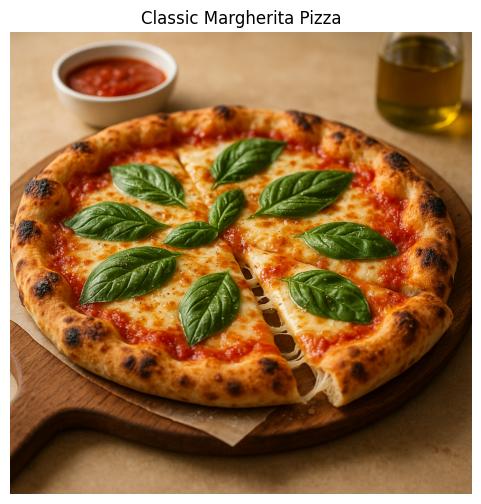

In [8]:
### Your Code Here
### Step 1.1: Load the JSON file
with open('Recipes.json', 'r', encoding='utf-8') as f:
    recipe_data = json.load(f)

### Step 1.2: Print each key-value pair of the first recipe
first_recipe = recipe_data[0]  # adjust index/key if needed

print("=== First Recipe Fields ===")
for key, value in first_recipe.items():
    value_type = type(value).__name__
    print(f"{key} ({value_type}): {value}")

### Step 1.3: Show the image of the first recipe
image_id = first_recipe['id']
image_path = f'synthetic_recipe_images/recipe{image_id}.png'

img = Image.open(image_path)
img_array = np.array(img)

plt.figure(figsize=(6, 6))
plt.imshow(img_array)
plt.axis('off')
plt.title(first_recipe.get('name', 'Recipe 1'))
plt.show()

### Step 2: Define the vision LLM with LLaMA

To generate meaningful textual descriptions from food images, you will use a vision-capable large language model (LLM). In this step, you will define and configure a **LLaMA-based vision model** that can process both images and text prompts.

You will initialize the model with the appropriate credentials and inference parameters, and verify that it accepts image inputs and produces descriptive captions. This model will serve as the core component for converting visual information into natural language that can be integrated with your existing JSON-based knowledge structure.

By completing this step, you will have a vision-enabled LLM ready to perform image captioning reliably and repeatably.


In [9]:
### Your Code Here: Fill in the blanks
import base64

def vision_llm(system_msg, prompt_txt, image_path):
    # Credentials of the model
    model_id = 'meta-llama/llama-4-maverick-17b-128e-instruct-fp8'
    project_id = "skills-network"
    credentials = Credentials(
        url="https://us-south.ml.cloud.ibm.com",
    )
    generate_params = {"max_tokens": 300}

    ### Step 2.1: Define the model by ModelInference
    model = ModelInference(
        model_id=model_id,
        credentials=credentials,
        project_id=project_id,
        params=generate_params
    )

    ### Step 2.2: Encode the input image to a base64 string
    with open(image_path, 'rb') as image_file:
        image_base64 = base64.b64encode(image_file.read()).decode('utf-8')

    ### Step 2.3: Define the messages for the model
    messages = [
        {"role": "system", "content": system_msg},
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {
                        "url": f"data:image/png;base64,{image_base64}"
                    }
                },
                {
                    "type": "text",
                    "text": prompt_txt
                }
            ]
        }
    ]

    ### Step 2.4: Get the response for the messages
    response = model.chat(messages=messages)
    output_text = response["choices"][0]["message"]["content"]
    return output_text

### Step 3: Design and validate prompts for the vision LLM

To ensure the vision LLM generates useful and consistent image captions, careful prompt design is essential. In this step, you will create a prompt that instructs the model to focus on relevant visual details, such as ingredients, cooking style, and presentation, while avoiding unnecessary or speculative information.

Once the prompt is defined, you will perform a simple unit test by running the model on a small sample of food images. This allows you to verify that the generated captions are accurate, concise, and suitable for integration into the existing JSON data structure.

By the end of this step, you will have a validated prompt that reliably converts food images into high-quality textual descriptions.


In [10]:
### Your Code Here

### Define the food image caption prompts given a food name.
### The food name, as you have noticed, comes from the corresponding recipe data.
### You want to include the food name to ensure the model focuses on it while giving captions.
def image_caption_prompt_template(food_name):
    image_caption_system_msg = """
    You are a food photography analyst. Your task is to generate concise, factual captions 
    for food images. Focus only on what is visually present: ingredients, cooking style, 
    presentation, portion size, and plating. Do not speculate or invent details not visible 
    in the image. Keep the caption to 2-3 sentences.
    """

    image_caption_prompt_txt = f"""
    This is an image of '{food_name}'. 
    Describe what you see in the image, focusing on the visible ingredients, 
    cooking method, presentation style, and overall appearance of the dish.
    """

    return image_caption_system_msg, image_caption_prompt_txt


### Step 3.2: Get the prompts with the food name of the first recipe
first_recipe = recipe_data[0]
food_name = first_recipe['name']
image_id = first_recipe['id']
image_path = f'synthetic_recipe_images/recipe{image_id}.png'

image_caption_system_msg, image_caption_prompt_txt = image_caption_prompt_template(food_name)

### Step 3.3: Get the test response and print it
response = vision_llm(
    system_msg=image_caption_system_msg,
    prompt_txt=image_caption_prompt_txt,
    image_path=image_path
)
print(response)

The image depicts a classic Margherita pizza, characterized by its round shape and golden-brown crust adorned with dark spots from the oven. The pizza is topped with a vibrant red sauce, melted white cheese, and fresh green basil leaves arranged in a circular pattern. A slice has been removed, revealing the gooey cheese beneath.

The pizza is presented on a wooden serving board, accompanied by a small white bowl of marinara sauce and a glass bottle of olive oil in the background. The overall presentation suggests a casual yet inviting dining setting, perfect for enjoying a delicious homemade or restaurant-style pizza. The image showcases the pizza's appetizing appearance, highlighting its key ingredients and cooking style.


### Step 4: Caption all images and augment the data

With a validated prompt and a working vision LLM, you will now scale the image captioning process across the entire dataset. In this step, you will iterate through all food images, generate captions for each one, and associate the results with their corresponding recipe or restaurant records.

You will then augment the existing JSON data by adding the generated image captions as new fields, ensuring the final structure remains consistent and machine-readable. This enriched dataset combines textual and visual insights into a unified representation, extending the structured knowledge base created in the previous lessons.

By the end of this step, you will have a multimodal JSON file that integrates image-derived descriptions with existing structured data, ready for downstream GenAI applications.


In [11]:
### Get captions for each image in the dataset and add to the JSON file
for i in range(len(recipe_data)):
    if (i+1) % 20 == 0:
        print(f'{i+1} out of {len(recipe_data)} is done')

    ### Step 4.1: Get the caption prompts
    food_name = recipe_data[i]['name']
    image_id = recipe_data[i]['id']
    image_path = f'synthetic_recipe_images/recipe{image_id}.png'
    image_caption_system_msg, image_caption_prompt_txt = image_caption_prompt_template(food_name)

    ### Step 4.2: Get the response with the prompts
    response = vision_llm(
        system_msg=image_caption_system_msg,
        prompt_txt=image_caption_prompt_txt,
        image_path=image_path
    )

    ### Save the response as another item in the recipe data
    recipe_data[i]['image_description'] = response

print('ALL DONE!')

### Save the augmented recipe data to a new JSON file
with open('augmented_recipes.json', 'w', encoding='utf-8') as f:
    json.dump(recipe_data, f, indent=4)

print('Augmented data saved to augmented_recipes.json')


20 out of 109 is done
40 out of 109 is done
60 out of 109 is done
80 out of 109 is done
100 out of 109 is done
ALL DONE!
Augmented data saved to augmented_recipes.json


Take a screenshot of the Python code, clearly showing your implementation and the output from Step 2. Name the screenshot ```M1L2_caption_all_recipes.jpg```. 


### Step 5: Save the image-caption-augmented recipe data

Save your data by running the following code.


In [12]:
filename = 'augmented_food_recipe.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(recipe_data, f, indent=4)

You can download the saved JSON file to your local folder. Be sure to store it in a safe location, as you will need it for future assignments.


----


## **Exercise 2: Preprocess the user visit history**

In this exercise, you will largely replicate the workflow from **Exercise 1**. The core steps, data exploration, prompt design, model inference, and JSON augmentation, remain the same.

The key difference lies in **prompt design**. Instead of focusing on food images, you will tailor your prompt to generate concise, informative descriptions from user visit history data, such as contextual cues from URLs or associated images combined with their written reviews. These prompts should emphasize elements that help explain user preferences and behavior while maintaining consistency with the existing JSON schema.

By the end of this exercise, you will have enriched the user visit history data with structured, machine-readable descriptions, further expanding the multimodal knowledge base built throughout this lab.


### Step 1: Load the user review data

Similar to Step 1 of Exercise 1, complete the following code block to load and explore the user review data.


In [14]:
### Part 1
### Your Code Here

### Step 1.1: Load the review dataset
with open('Synthetic-User-Reviews.json', 'r', encoding='utf-8') as f:
    user_review_data = json.load(f)

### Step 1.2: Print the first review by key-value pairs
first_review = user_review_data[0]
print("=== First User Review Fields ===")
for key, value in first_review.items():
    value_type = type(value).__name__
    print(f"{key} ({value_type}): {value}")

=== First User Review Fields ===
reviewId (int): 900000001
userId (str): USER_FUSION_FINDER_99
itemId (int): 1000001
title (str): A bit pricey, but that greenhouse vibe is so cozy
text (str): The Gilded Artichoke is definitely an upscale splurge. The lavender-rubbed chicken is unique, almost giving me tea-smoked vibes. It's a gorgeous, plant-filled escape from the city, though your wallet will feel it.
date (str): 2025-11-15
rating (float): 4.5
language (str): en
images (str): ['https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/L0HyLOGuAlxwKZaCC8sJdg/Gemini-Generated-Image-523rkg523rkg523r.png','https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/YLCD9AYY985XxvP-K8CRbA/Gemini-Generated-Image-hy4y8why4y8why4y.png']


Let's look at the 'images' item. Although it looks like a list, it is actually a list in string type. Therefore, you need to be careful and convert the string to the actual Python list. Complete the code block below to display the first review image of the first restaurant visit.


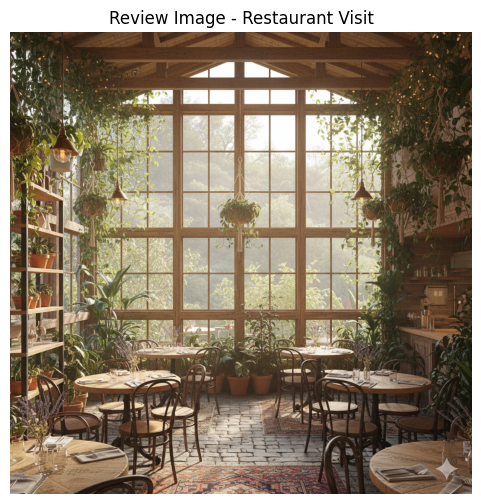

In [15]:
### Part 2
import ast
import requests

### Step 1.3: Convert the string representation of list to actual Python list
images_list = ast.literal_eval(first_review['images'])

### Step 1.4: Use requests.get() to fetch the image content
image_url = images_list[0]
image_response = requests.get(image_url)

### Step 1.5: Write the image content to a temporary file
with open('review_image_placeholder.jpg', 'wb') as f:
    f.write(image_response.content)

### Step 1.6: Open and show the image
img = Image.open('review_image_placeholder.jpg')
img_array = np.array(img)

plt.figure(figsize=(6, 6))
plt.imshow(img_array)
plt.axis('off')
plt.title(f"Review Image - {first_review.get('name', 'Restaurant Visit')}")
plt.show()

### Step 2: Define the prompt and the validation

Again, you will design a prompt template for the vision task and perform a unit test to validate the model’s behavior. However, unlike the previous exercise, this prompt must **incorporate textual context from user reviews** to guide the image captioning process.

In this step, you will define a prompt template function that takes user review text as input and uses it as contextual information when describing a food image. The system message assigns the model the role of a culinary expert, while the prompt instructs the model to generate a concise image description that aligns with the sentiment and details expressed in the reviews.

After defining the prompt template, you will perform a unit test by running the vision LLM on a single image and its associated reviews. This test allows you to verify that the generated caption effectively combines visual information from the image with contextual cues from the reviews before applying the prompt at scale in later steps.


In [16]:
### Step 2.1: Define the prompt template
def review_context_image_caption_prompt_template(reviews):
    review_context_image_caption_system_msg = """
    You are a culinary expert and food critic. Your task is to generate concise, insightful 
    image descriptions for restaurant food photos, informed by the context of user reviews.
    Focus on visible dish qualities such as ingredients, presentation, portion size, and 
    cooking style. Align your description with the sentiment and specific details mentioned 
    in the reviews. Keep the description to 2-3 sentences and do not invent details not 
    visible in the image or mentioned in the reviews.
    """

    review_context_image_caption_prompt_txt = f"""
    The following are user reviews for this dish:
    {reviews}

    Using the reviews above as context, describe what you see in the image.
    Focus on the visible ingredients, presentation, and how the dish aligns with 
    the experiences described in the reviews.
    """

    return review_context_image_caption_system_msg, review_context_image_caption_prompt_txt


### Step 2.2: Get the prompts using the first review's text
reviews = first_review.get('reviews', '')
review_context_image_caption_system_msg, review_context_image_caption_prompt_txt = \
    review_context_image_caption_prompt_template(reviews)

### Step 2.3: Get the response from the vision LLM
response = vision_llm(
    system_msg=review_context_image_caption_system_msg,
    prompt_txt=review_context_image_caption_prompt_txt,
    image_path='review_image_placeholder.jpg'
)
print(response)

There is no dish in the image. The image depicts a serene and inviting restaurant interior with a sunroom-style dining area. The room is filled with lush greenery, including potted plants on shelves and hanging from the ceiling, creating a natural ambiance. Several round wooden tables are set with place settings, surrounded by metal chairs, and arranged on a cobblestone floor adorned with a patterned rug.


### Step 3: Caption all images and augment the data

Now, you are ready to get all captions with a for loop! Complete and run the following code block to caption all the review images.


In [17]:
from tenacity import retry, stop_after_attempt, wait_exponential

### URL Request function with Retry
@retry(stop=stop_after_attempt(10), wait=wait_exponential(multiplier=1, min=1, max=10))
def get_data_with_retry(url):
    response = requests.get(url, timeout=5)
    response.raise_for_status()
    return response

### Start the for loop
for i in range(len(user_review_data)):
    if (i+1) % 20 == 0:
        print(f'{i+1} out of {len(user_review_data)} is done')

    ### Step 3.1: Convert the string to the Python list of image urls
    review_images = ast.literal_eval(user_review_data[i]['images'])

    review_image_captions = []
    if len(review_images) > 0:
        for img_url in review_images:
            try:
                ### Step 3.2: Use get_data_with_retry to get the image data
                image_data = get_data_with_retry(img_url)
                print("Success!")
            except Exception as e:
                print(f"All retries failed at url {img_url}:", e)
                continue

            image = image_data.content
            with open('review_image_placeholder.jpg', 'wb') as img_file:
                img_file.write(image)

            ### Step 3.3: Get the prompts, get the response, append to review_image_captions
            reviews = user_review_data[i].get('reviews', '')
            review_context_image_caption_system_msg, review_context_image_caption_prompt_txt = \
                review_context_image_caption_prompt_template(reviews)

            response = vision_llm(
                system_msg=review_context_image_caption_system_msg,
                prompt_txt=review_context_image_caption_prompt_txt,
                image_path='review_image_placeholder.jpg'
            )
            review_image_captions.append(response)

    ### Append the review_image_captions to the review data
    user_review_data[i]['image_captions'] = review_image_captions

print('ALL DONE!')

Success!
Success!
Success!
Success!
Success!
Success!
Success!
Success!
Success!
ALL DONE!
Augmented data saved to augmented_user_reviews.json


### Step 4: Save the image-caption-augmented user review data


Run the following code block to save the augmented review data:


In [ ]:
filename = 'augmented_user_review.json'
with open(filename, 'w', encoding='utf-8') as f:
    json.dump(user_review_data, f, indent=4)
print('Augmented data saved to augmented_user_reviews.json')

You can download the saved JSON file to your local folder. Be sure to store it in a safe location, as you will need it for future assignments.


----


## **Conclusion**

You have successfully applied GenAI tools to transform the unstructured text data into a well-structured JSON file!

----


## Authors


[Jianping (Mike) Ye](https://www.linkedin.com/in/jianping-ye/)


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2026-02-03|1|Jianping Ye|Create lab|
|2026-02-10|2|Jojy John|ID Reviewed|-->



©IBM Corporation. All rights reserved.
